# **Limpieza de dataframe 1**

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


## **Carga de datos**

In [5]:
df = pd.read_csv("../data/customer_activity.csv")
df.head()

,customer_id,first_name,last_name,email,active,address,district,postal_code,city,country,rental_id,rental_date,return_date,payment_id,payment_date,amount,rental_duration
0,130,charlotte,hunter,charlotte.hunter@sakilacustomer.org,1,758 junan lane,gois,82639,águas lindas de goiás,brazil,1,2005-05-24 22:53:30,2005-05-26 22:04:30,3504,2005-05-24 22:53:30,2.99,2
1,459,tommy,collazo,tommy.collazo@sakilacustomer.org,1,76 kermanshah manor,esfahan,23343,qomsheh,iran,2,2005-05-24 22:54:33,2005-05-28 19:40:33,12377,2005-05-24 22:54:33,2.99,4
2,408,manuel,murrell,manuel.murrell@sakilacustomer.org,1,692 amroha drive,northern,35575,jaffna,sri lanka,3,2005-05-24 23:03:39,2005-06-01 22:12:39,11032,2005-05-24 23:03:39,3.99,8
3,333,andrew,purdy,andrew.purdy@sakilacustomer.org,1,431 szkesfehrvr avenue,baki,57828,baku,azerbaijan,4,2005-05-24 23:04:41,2005-06-03 01:43:41,8987,2005-05-24 23:04:41,4.99,10
4,222,delores,hansen,delores.hansen@sakilacustomer.org,1,810 palghat (palakkad) boulevard,jaroslavl,73431,jaroslavl,russian federation,5,2005-05-24 23:05:21,2005-06-02 04:33:21,6003,2005-05-24 23:05:21,6.99,9


## **Analisis exploratorio**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      15861 non-null  int64  
 1   first_name       15861 non-null  object 
 2   last_name        15861 non-null  object 
 3   email            15861 non-null  object 
 4   active           15861 non-null  int64  
 5   address          15861 non-null  object 
 6   district         15761 non-null  object 
 7   postal_code      15861 non-null  int64  
 8   city             15861 non-null  object 
 9   country          15861 non-null  object 
 10  rental_id        15861 non-null  int64  
 11  rental_date      15861 non-null  object 
 12  return_date      15861 non-null  object 
 13  payment_id       15861 non-null  int64  
 14  payment_date     15861 non-null  object 
 15  amount           15861 non-null  float64
 16  rental_duration  15861 non-null  int64  
dtypes: float64(1

### **Comprobacion de nulos**

In [7]:
df.isnull().sum()

customer_id          0
first_name           0
last_name            0
email                0
active               0
address              0
district           100
postal_code          0
city                 0
country              0
rental_id            0
rental_date          0
return_date          0
payment_id           0
payment_date         0
amount               0
rental_duration      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### **Detectar Outliers**

In [ ]:
df.describe()

,customer_id,active,postal_code,rental_id,payment_id,amount,rental_duration
count,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000,15861.000000
mean,297.259567,0.974781,50452.519324,7959.654562,8027.491268,4.217161,5.025219
std,172.375305,0.156795,28910.703531,4616.463306,4630.658068,2.360383,2.611835
min,1.000000,0.000000,3.000000,1.000000,1.000000,0.990000,0.000000
25%,148.000000,1.000000,25238.000000,3968.000000,4015.000000,2.990000,3.000000
50%,296.000000,1.000000,51309.000000,7934.000000,8033.000000,3.990000,5.000000
75%,446.000000,1.000000,75149.000000,11920.000000,12036.000000,4.990000,7.000000
max,599.000000,1.000000,99865.000000,16049.000000,16049.000000,11.990000,10.000000


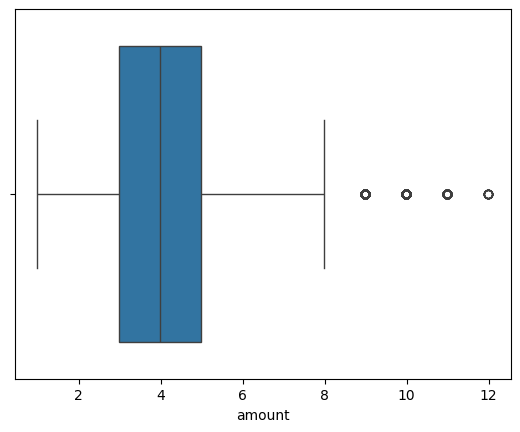

In [17]:
sns.boxplot(x=df['amount'])
plt.show()

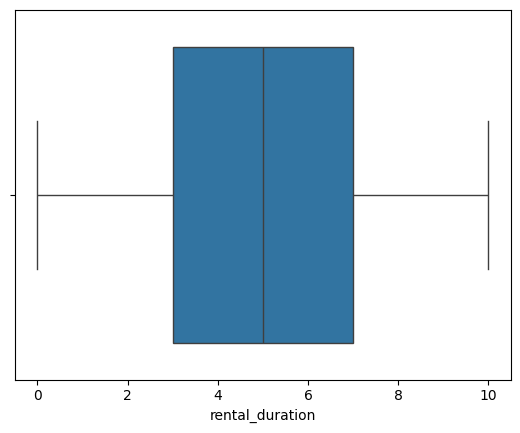

In [18]:
sns.boxplot(x=df['rental_duration'])
plt.show()

Se han analizado amount y rental_duration porque son variables numéricas clave para entender el comportamiento de los datos.
En amount, describe() y el boxplot muestran la mayoría de valores concentrados entre 2.99 y 4.99, pero con algunos valores más altos que aparecen como posibles outliers. En cambio, rental_duration se concentra entre 3 y 7 días y no presenta puntos fuera de los bigotes, lo que indica una distribución estable sin outliers estadísticos.

In [10]:
# Conversión a datetime
df['rental_date'] = pd.to_datetime(df['rental_date'], errors='coerce')
df['return_date'] = pd.to_datetime(df['return_date'], errors='coerce')
df['payment_date'] = pd.to_datetime(df['payment_date'], errors='coerce')
# Verificamos si hay nulos después de la conversión
print(f"Nulos en rental_date: {df['rental_date'].isna().sum()}")
print(f"Nulos en return_date: {df['return_date'].isna().sum()}")
print(f"Nulos en payment_date: {df['payment_date'].isna().sum()}")
# Si hay nulos, los eliminamos para poder operar
df = df.dropna(subset=['rental_date', 'return_date'])

Nulos en rental_date: 0
Nulos en return_date: 0
Nulos en payment_date: 0


### **Substitucion de nulos**

In [13]:
df['district'] = df['district'].fillna('Sin Datos')

### **Normalizar cadenas**

In [26]:
# Aplicar lower y trim a todas las columnas de texto
columnas_texto = df.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df[col] = df[col].str.lower().str.strip()
df.head()

,customer_id,first_name,last_name,email,active,address,district,postal_code,city,country,rental_id,rental_date,return_date,payment_id,payment_date,amount,rental_duration
0,130,charlotte,hunter,charlotte.hunter@sakilacustomer.org,1,758 junan lane,gois,82639,águas lindas de goiás,brazil,1,2005-05-24 22:53:30,2005-05-26 22:04:30,3504,2005-05-24 22:53:30,2.99,2
1,459,tommy,collazo,tommy.collazo@sakilacustomer.org,1,76 kermanshah manor,esfahan,23343,qomsheh,iran,2,2005-05-24 22:54:33,2005-05-28 19:40:33,12377,2005-05-24 22:54:33,2.99,4
2,408,manuel,murrell,manuel.murrell@sakilacustomer.org,1,692 amroha drive,northern,35575,jaffna,sri lanka,3,2005-05-24 23:03:39,2005-06-01 22:12:39,11032,2005-05-24 23:03:39,3.99,8
3,333,andrew,purdy,andrew.purdy@sakilacustomer.org,1,431 szkesfehrvr avenue,baki,57828,baku,azerbaijan,4,2005-05-24 23:04:41,2005-06-03 01:43:41,8987,2005-05-24 23:04:41,4.99,10
4,222,delores,hansen,delores.hansen@sakilacustomer.org,1,810 palghat (palakkad) boulevard,jaroslavl,73431,jaroslavl,russian federation,5,2005-05-24 23:05:21,2005-06-02 04:33:21,6003,2005-05-24 23:05:21,6.99,9


### **Corregir tipos numericos**

In [29]:
df['postal_code'] = df['postal_code'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      15861 non-null  int64         
 1   first_name       15861 non-null  object        
 2   last_name        15861 non-null  object        
 3   email            15861 non-null  object        
 4   active           15861 non-null  int64         
 5   address          15861 non-null  object        
 6   district         15861 non-null  object        
 7   postal_code      15861 non-null  object        
 8   city             15861 non-null  object        
 9   country          15861 non-null  object        
 10  rental_id        15861 non-null  int64         
 11  rental_date      15861 non-null  datetime64[ns]
 12  return_date      15861 non-null  datetime64[ns]
 13  payment_id       15861 non-null  int64         
 14  payment_date     15861 non-null  datet

### **Detectar Outliers**

A partir de describe() y los boxplots, se observa que amount presenta algunos valores más altos que el rango central, apareciendo como posibles outliers en la visualización, aunque corresponden a precios reales del sistema. En cambio, rental_duration muestra una distribución estable sin valores atípicos visibles. No se eliminan registros, ya que forman parte del comportamiento natural de los datos.

### **Crear columnas derivadas utiles**

In [34]:
df['rental_month'] = df['rental_date'].dt.month
df.head()

,customer_id,first_name,last_name,email,active,address,district,postal_code,city,country,rental_id,rental_date,return_date,payment_id,payment_date,amount,rental_duration,rental_duration_days,rental_day_name,rental_month
0,130,charlotte,hunter,charlotte.hunter@sakilacustomer.org,1,758 junan lane,gois,82639,águas lindas de goiás,brazil,1,2005-05-24 22:53:30,2005-05-26 22:04:30,3504,2005-05-24 22:53:30,2.99,2,1,Tuesday,5
1,459,tommy,collazo,tommy.collazo@sakilacustomer.org,1,76 kermanshah manor,esfahan,23343,qomsheh,iran,2,2005-05-24 22:54:33,2005-05-28 19:40:33,12377,2005-05-24 22:54:33,2.99,4,3,Tuesday,5
2,408,manuel,murrell,manuel.murrell@sakilacustomer.org,1,692 amroha drive,northern,35575,jaffna,sri lanka,3,2005-05-24 23:03:39,2005-06-01 22:12:39,11032,2005-05-24 23:03:39,3.99,8,7,Tuesday,5
3,333,andrew,purdy,andrew.purdy@sakilacustomer.org,1,431 szkesfehrvr avenue,baki,57828,baku,azerbaijan,4,2005-05-24 23:04:41,2005-06-03 01:43:41,8987,2005-05-24 23:04:41,4.99,10,9,Tuesday,5
4,222,delores,hansen,delores.hansen@sakilacustomer.org,1,810 palghat (palakkad) boulevard,jaroslavl,73431,jaroslavl,russian federation,5,2005-05-24 23:05:21,2005-06-02 04:33:21,6003,2005-05-24 23:05:21,6.99,9,8,Tuesday,5


### **Graficos**

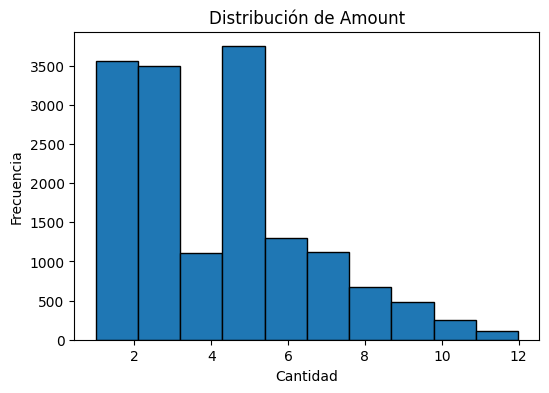

In [38]:
plt.figure(figsize=(6,4))
plt.hist(df['amount'], bins=10, edgecolor='black')
plt.title('Distribución de Amount')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()

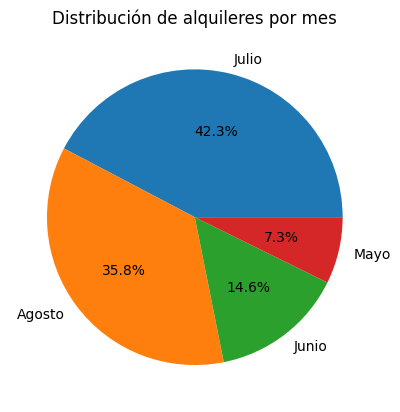

In [40]:
month_map = {
5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto"}

data = df['rental_month'].map(month_map).value_counts()

plt.figure()
plt.pie(data, labels=data.index, autopct='%1.1f%%')
plt.title('Distribución de alquileres por mes')
plt.show()

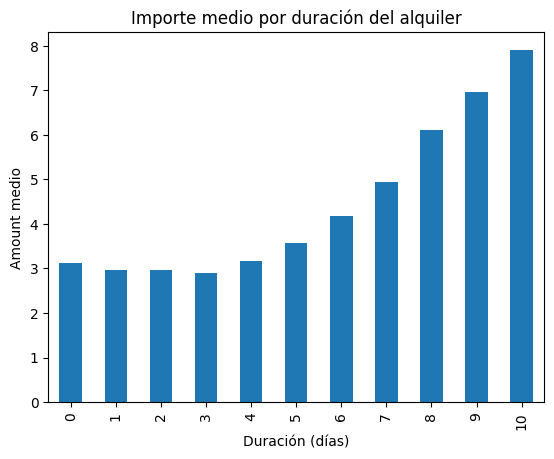

In [42]:
grouped = df.groupby('rental_duration')['amount'].mean()

plt.figure()
grouped.plot(kind='bar')
plt.title('Importe medio por duración del alquiler')
plt.xlabel('Duración (días)')
plt.ylabel('Amount medio')
plt.show()